## Monte Carlo - Forecasting Stock Prices -

Forecasting Future Stock Prices – continued:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# The pdr_override function is causing an AttributeError.
# Instead of using pandas_datareader with pdr_override,
# we will use yfinance.download directly for data retrieval,
# which is a more stable and recommended approach.
# The 'pip install' line has already been executed successfully.

# from pandas_datareader import data as wb # No longer needed if using yf.download
from scipy.stats import norm
%matplotlib inline

ticker = 'ADANIENT.NS'
# Fetch data directly using yf.download and ensure it's a DataFrame with the correct column name
data = yf.download(ticker, start='2010-01-01', end='2021-12-31')[['Close']]
data.columns = [ticker]

log_returns = np.log(1 + data.pct_change())
u = log_returns.mean()
var = log_returns.var()
drift = u - (0.5 * var)
stdev = log_returns.std()

drift.values
stdev.values

t_intervals = 250
iterations = 1000

daily_returns = np.exp(drift.values + stdev.values * norm.ppf(np.random.rand(t_intervals, iterations)))

[*********************100%***********************]  1 of 1 completed


***

Create a variable S0 equal to the last adjusted closing price of Microsoft. Use the “iloc” method.

In [6]:
S0 = data.iloc[-1]
S0

,2021-12-30
ADANIENT.NS,1693.378296


Create a variable price_list with the same dimension as the daily_returns matrix.

In [7]:
price_list = np.zeros_like(daily_returns)
price_list

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
price_list[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Set the values on the first row of the price_list array equal to S0.

In [9]:
price_list[0] = S0
price_list

array([[1693.3782959, 1693.3782959, 1693.3782959, ..., 1693.3782959,
        1693.3782959, 1693.3782959],
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       ...,
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
           0.       ,    0.       ]])

Create a loop in the range (1, t_intervals) that reassigns to the price in time t the product of the price in day (t-1) with the value of the daily returns in t.

In [10]:
for t in range(1, t_intervals):
    price_list[t] = price_list[t - 1] * daily_returns[t]

In [11]:
price_list

array([[1693.3782959 , 1693.3782959 , 1693.3782959 , ..., 1693.3782959 ,
        1693.3782959 , 1693.3782959 ],
       [1667.75040153, 1709.61790144, 1622.31057501, ..., 1811.63351708,
        1709.32098078, 1631.86195158],
       [1719.62109214, 1730.52588243, 1603.53381377, ..., 1795.78302851,
        1658.44005557, 1736.45663097],
       ...,
       [ 855.15649524, 1263.67169942, 3101.70620805, ..., 2121.26327965,
        1676.78424538, 4328.98616677],
       [ 884.93430493, 1303.01267934, 3072.45871112, ..., 2103.2527308 ,
        1706.52719598, 4405.47032108],
       [ 886.41770658, 1292.94958739, 3110.44840575, ..., 1965.56072196,
        1764.22890876, 4406.59747146]])

Finally, plot the obtained price list data.

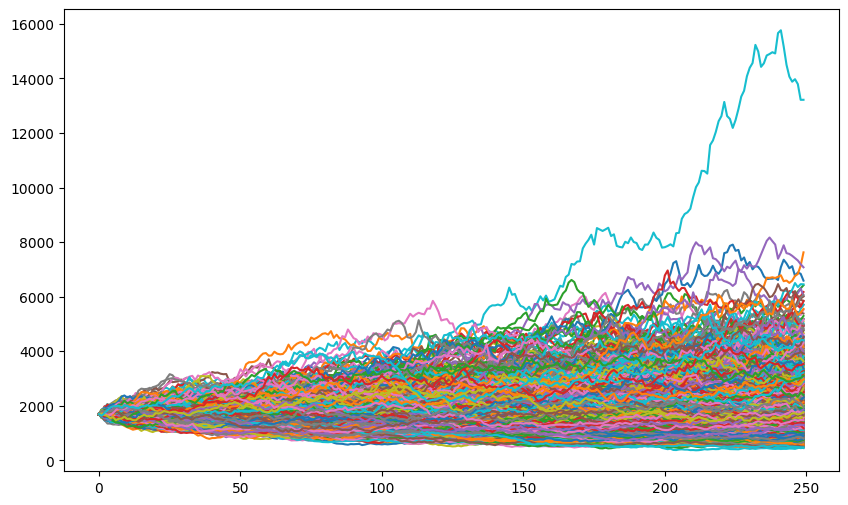

In [12]:
plt.figure(figsize=(10,6))
plt.plot(price_list);

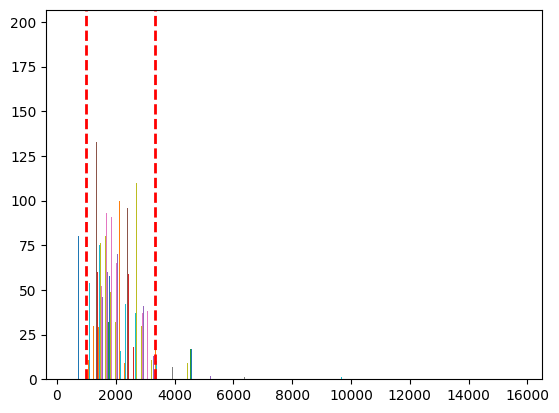

In [13]:
plt.hist(price_list,bins=50)
plt.axvline(np.percentile(price_list,5), color='r', linestyle='dashed', linewidth=2)
plt.axvline(np.percentile(price_list,95), color='r', linestyle='dashed', linewidth=2)
plt.show()

In [14]:
#use numpy mean function to calculate the mean of the result
print(round(np.mean(price_list),2))

1922.89


In [15]:
print("5% quantile =",np.percentile(price_list,5))
print("10% quantile =",np.percentile(price_list,10))
print("20% quantile =",np.percentile(price_list,10))
print("30% quantile =",np.percentile(price_list,10))
print("40% quantile =",np.percentile(price_list,10))
print("50% quantile =",np.percentile(price_list,10))
print("60% quantile =",np.percentile(price_list,90))
print("70% quantile =",np.percentile(price_list,10))
print("80% quantile =",np.percentile(price_list,10))
print("90% quantile =",np.percentile(price_list,90))
print("95% quantile =",np.percentile(price_list,95))

5% quantile = 999.3036522484367
10% quantile = 1170.739056150161
20% quantile = 1170.739056150161
30% quantile = 1170.739056150161
40% quantile = 1170.739056150161
50% quantile = 1170.739056150161
60% quantile = 2822.8220415581604
70% quantile = 1170.739056150161
80% quantile = 1170.739056150161
90% quantile = 2822.8220415581604
95% quantile = 3331.508146107012


[*********************100%***********************]  3 of 3 completed


Portfolio Monte Carlo VaR Results
Confidence Level: 95%
1-Day VaR: 1.40%
Expected Shortfall: 1.77%


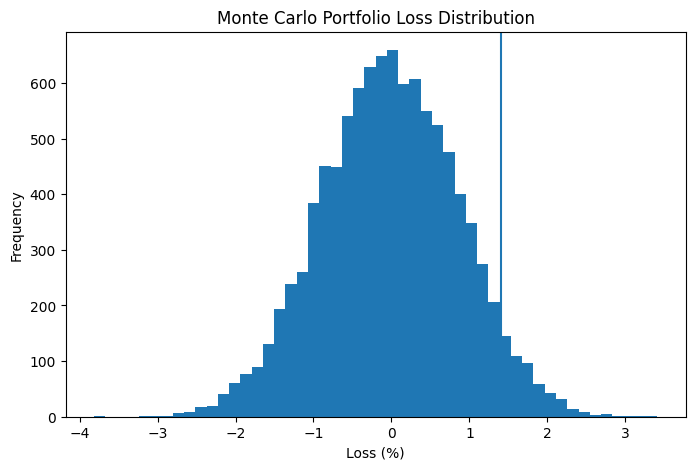

In [17]:
# ==============================
# PORTFOLIO MONTE CARLO VAR
# USING REAL NSE STOCK DATA
# ==============================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ------------------------------
# 1. INPUT SECTION
# ------------------------------

tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS"]
weights = np.array([0.4, 0.3, 0.3])   # Portfolio weights
start_date = "2023-01-01"
end_date = "2025-02-28"
confidence_level = 95
simulations = 10000

# ------------------------------
# 2. DOWNLOAD DATA
# ------------------------------

data = yf.download(tickers, start=start_date, end=end_date)["Close"]
returns = data.pct_change().dropna()

# ------------------------------
# 3. ESTIMATE PARAMETERS
# ------------------------------

mu = returns.mean().values              # Mean daily return
cov_matrix = returns.cov().values       # Covariance matrix

# ------------------------------
# 4. CHOLESKY DECOMPOSITION
# ------------------------------

L = np.linalg.cholesky(cov_matrix)

# ------------------------------
# 5. MONTE CARLO SIMULATION
# ------------------------------

np.random.seed(42)

simulated_portfolio_returns = []

for i in range(simulations):

    Z = np.random.normal(size=len(tickers))   # Independent shocks
    correlated_Z = L @ Z                     # Correlated shocks

    simulated_returns = mu + correlated_Z    # Simulated asset returns

    portfolio_return = np.dot(weights, simulated_returns)
    simulated_portfolio_returns.append(portfolio_return)

simulated_portfolio_returns = np.array(simulated_portfolio_returns)

# ------------------------------
# 6. CALCULATE VaR & ES
# ------------------------------

portfolio_losses = -simulated_portfolio_returns

VaR = np.percentile(portfolio_losses, confidence_level)
ES = portfolio_losses[portfolio_losses >= VaR].mean()

print("=================================")
print("Portfolio Monte Carlo VaR Results")
print("=================================")
print(f"Confidence Level: {confidence_level}%")
print(f"1-Day VaR: {VaR*100:.2f}%")
print(f"Expected Shortfall: {ES*100:.2f}%")
print("=================================")

# ------------------------------
# 7. VISUALIZATION
# ------------------------------

plt.figure(figsize=(8,5))
plt.hist(portfolio_losses*100, bins=50)
plt.axvline(VaR*100)
plt.title("Monte Carlo Portfolio Loss Distribution")
plt.xlabel("Loss (%)")
plt.ylabel("Frequency")
plt.show()

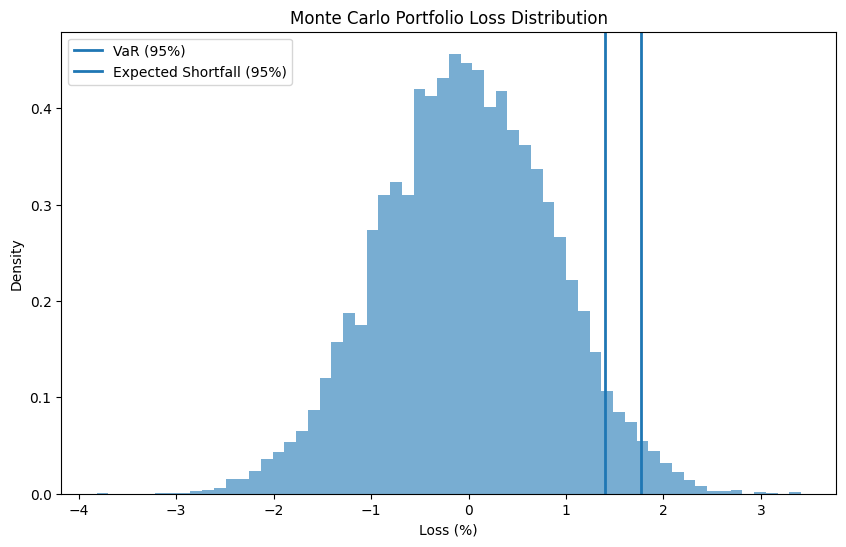

In [18]:
# ------------------------------
# VISUALIZATION: Monte Carlo VaR
# ------------------------------

plt.figure(figsize=(10,6))

# Histogram of simulated portfolio losses
plt.hist(portfolio_losses*100, bins=60, density=True, alpha=0.6)

# VaR line
plt.axvline(VaR*100, linewidth=2)

# Expected Shortfall line
plt.axvline(ES*100, linewidth=2)

plt.title("Monte Carlo Portfolio Loss Distribution")
plt.xlabel("Loss (%)")
plt.ylabel("Density")
plt.legend(["VaR (95%)", "Expected Shortfall (95%)"])
plt.show()